# Estudando a biblioteca `Pandas`
Pandas é uma biblioteca para trabalhar com tabelas, parecida com o Excel, mas dentro do Python. Existem só duas estruturas que você precisa conhecer:

* Series: uma coluna (uma lista de valores, cada um com um rótulo).
* DataFrame: uma tabela inteira (várias colunas juntas).

In [21]:
import pandas as pd
import numpy as np
from itables import show
from IPython.display import display, HTML

np.random.seed(42)
n = 404

#Usa pd.DataFrame para criar uma tabela 
tabela = pd.DataFrame({
    "no": range(n),
    "grau": np.random.exponential(scale=0.02, size=n),
    "intermediacao": np.random.exponential(scale=0.005, size=n),
    "proximidade": np.random.uniform(0.1, 0.4, size=n),
    "autovetor": np.random.exponential(scale=0.03, size=n),
    "comunidade": np.random.randint(0, 6, size=n),
})

# Força texto preto e fundo branco na tabela (tema escuro do editor)
display(HTML("""
<style>
.dt-container, .dt-container *,
table.dataTable th, table.dataTable td,
.dataTables_wrapper, .dataTables_wrapper * {
    color: black !important;
}
table.dataTable, table.dataTable tbody tr {
    background-color: white !important;
}
</style>
"""))

show(
    tabela,
    columnDefs=[{"targets": "_all", "orderSequence": ["desc", "asc"]},
    {"targets": [0,5], "orderable": False}],
    order=[[1, "desc"]],
    pageLength=15,
    lengthMenu=[10, 15, 25, 50],
)

## Entendendo o `itable`
`Show` é a função do itables que pega um DataFrame e o exibe como tabela interativa. O primeiro argumento é o DataFrame (tabela). Tudo que vem depois é configuração opcional.

`ColumnDefs` significa "definições de colunas". É uma lista de regras, e cada regra é um dicionário com duas partes:
* "targets": "_all" diz a quais colunas a regra se aplica. "_all" quer dizer todas. Você poderia mirar só algumas, por posição, como "targets": [1, 2] (só grau e intermediação).
* "orderSequence": ["desc", "asc"] define o que acontece a cada clique no cabeçalho. O primeiro clique ordena em ordem decrescente (desc, do maior para o menor), e o segundo em crescente (asc).

`Order` define a ordenação inicial, aquela com que a tabela aparece antes de você clicar em qualquer coisa. Note os colchetes duplos: a lista de fora é a lista de critérios, e cada critério é um par [posição da coluna, direção].

`pageLength` É quantas linhas aparecem por página ao abrir a tabela.

`lengthMenu` são as opções do seletor "Show ___ entries", em que você escolhe quantas linhas ver por página.

`orderable: False` uma regra no columnDefs apontando para as colunas que não devem ordenar.

## Gráficos interessantes de usar

### Top 10 nós de cada centralidade
* O método `.nlargest(tamanho,coluna)` serve para pegar os maiores valores de uma coluna.
* O `plot()` manda construir o gráfico
* `x=''`, no eixo X coloque ''.
* `y=''`, A altura das barras será determinada pelo valor da ''
* `kind=''` indica o tipo de gráfico, pode ser de barra, histograma, linha, dispersão...

<Axes: xlabel='no'>

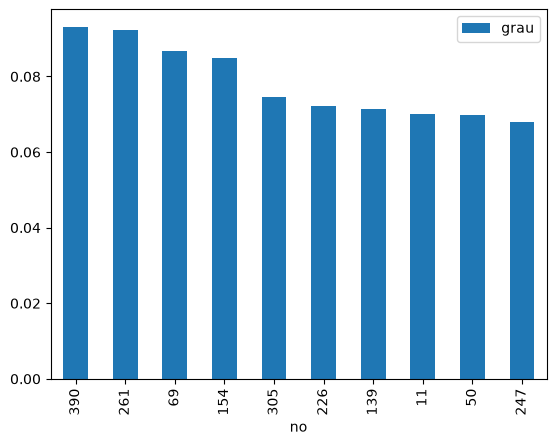

In [25]:
tabela.nlargest(10, 'grau').plot(
    x='no',
    y='grau',
    kind='bar'
)

### Comparação entre duas centralidades
* `tabela.plot.scatter` Crie um gráfico de dispersão usando os dados da tabela.
* `x=''`, no eixo X coloque ''.
* `y=''`, A altura das barras será determinada pelo valor da ''

<Axes: title={'center': 'grau'}, xlabel='comunidade'>

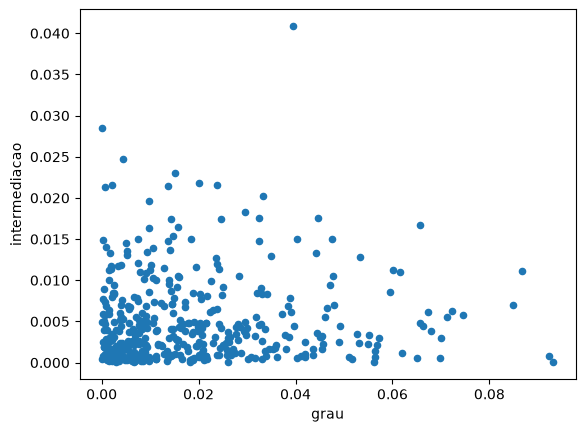

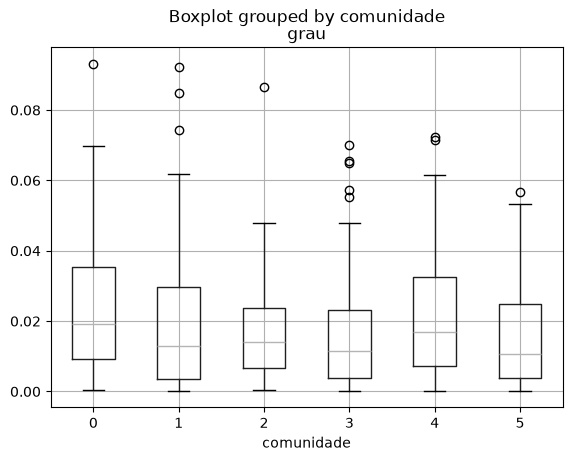

In [ ]:
tabela.plot.scatter(
    x='grau',
    y='intermediacao'
)

### Quantidade de usuários por comunidade
* `tabela['coluna']` seleciona somente essa coluna
* O `.value_counts()` conte quantas vezes cada valor aparece.
* O `.sort_index()` ordena por meio do indice
* `kind=''` indica o tipo de gráfico, pode ser de barra, histograma, linha, dispersão...

<Axes: xlabel='comunidade'>

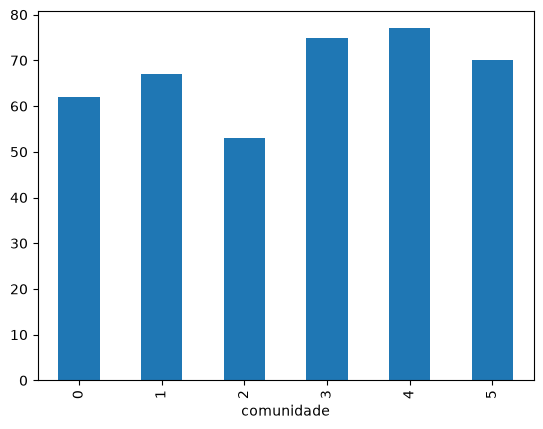

In [30]:
tabela['comunidade'].value_counts().sort_index().plot(
    kind='bar'
)

## Histograma dos graus
* `tabela['grau']` pega os valores do grau
* `bins=` são as faixas do histograma

<Axes: ylabel='Frequency'>

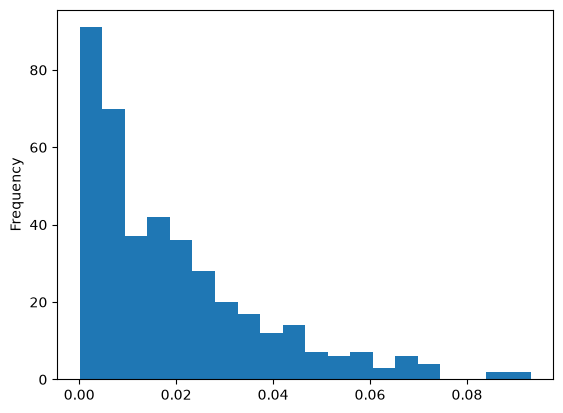

In [31]:
tabela['grau'].plot(
    kind='hist',
    bins=20
)

## Média das centralidades por comunidade
* `groupby` agrupe as linhas de acordo com determinada característica.
* `['grau', 'intermediacao', 'proximidade', 'autovetor']` Desses grupos, eu só quero analisar essas quatro colunas.
* `.mean()` calcula a média de cada métrica para cada comunidade.

<Axes: xlabel='comunidade'>

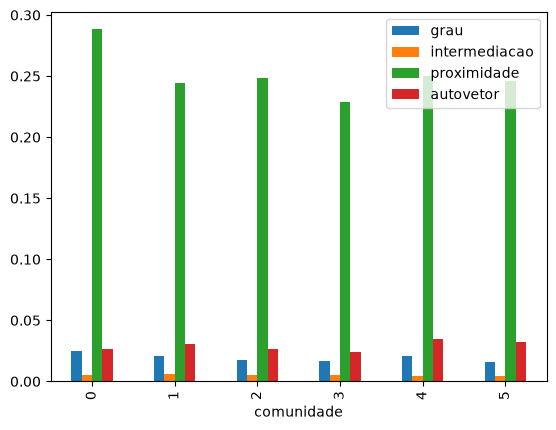

In [33]:
media_comunidades = tabela.groupby('comunidade')[
    ['grau', 'intermediacao', 'proximidade', 'autovetor']
].mean()
media_comunidades.plot(
    kind='bar'
)